In [14]:
import os
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np

# Imports from PyTorch.
import torch
import torchvision
from torch import nn
from torchvision import datasets, transforms
from torch import nn, Tensor, device, no_grad, manual_seed
from torch import max as torch_max
from torch.utils.data import DataLoader
from torchvision.datasets.utils import download_url
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.functional as F
from copy import deepcopy

import sys
# get the path of the current file
file = os.path.abspath('')
path = os.path.join(file, '../../src')
sys.path.append(path)
print(path)


# Imports from aihwkit.
from aihwkit.nn import AnalogConv2d, AnalogLinear, AnalogSequential
from aihwkit.optim import AnalogSGD
from aihwkit.simulator.configs.configs import (
    InferenceRPUConfig,
    # remember, the InferenceRPUConfig configuration parameter is used only for inference:
    # this means that the hardware non-idealities are considered only in the forward pass,
    # while the backward and update passes are ideal.
)
from aihwkit.simulator.configs import MappingParameter
from aihwkit.simulator.configs import (
    SingleRPUConfig,
    FloatingPointRPUConfig,
    ConstantStepDevice,
    FloatingPointDevice,
)


from aihwkit.simulator.parameters import (
    WeightClipParameter,
    WeightQuantizerParameter,
)
from aihwkit.simulator.parameters.enums import WeightQuantizerType

from aihwkit.nn.conversion import convert_to_analog, convert_to_digital
from aihwkit.simulator.presets import StandardHWATrainingPreset
from aihwkit.simulator.parameters.enums import WeightClipType

from aihwkit.simulator.rpu_base import cuda

from aihwkit.nn.conversion import convert_to_analog
src = os.getcwd()
src = os.path.abspath(os.path.join(src, '../src'))
sys.path.append(src)

import plotting as pl



# Check device
USE_CUDA = 0
if cuda.is_compiled():
    USE_CUDA = 1

if USE_CUDA:
    torch.cuda.set_device(0)
DEVICE = torch.device("cuda:0" if USE_CUDA else "cpu")
print("Device: ", DEVICE)


cur_dir = os.getcwd()
print("Current directory: ", cur_dir)


# Path to store datasets
PATH_DATASET = os.path.join(cur_dir, "../data/cifar10")
print("Path to store datasets: ", PATH_DATASET)



# Training parameters
SEED = 1
N_EPOCHS = 30
BATCH_SIZE = 64
LEARNING_RATE = 0.0001
N_CLASSES = 10
use_fine_tune = True

/home/ecabiati/cellar/aihwkit/sandbox/cuda/../../src
Device:  cuda:0
Current directory:  /home/ecabiati/cellar/aihwkit/sandbox/cuda
Path to store datasets:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/../data/cifar10


In [11]:
class LambdaLayer(torch.nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)


class BasicBlock(torch.nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, option="A", RPU_CONFIG=None):
        super(BasicBlock, self).__init__()
        self.conv1 = AnalogConv2d(
            in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn1 = torch.nn.BatchNorm2d(planes)
        self.conv2 = AnalogConv2d(
            planes, planes, kernel_size=3, stride=1, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn2 = torch.nn.BatchNorm2d(planes)

        self.shortcut = AnalogSequential()
        if stride != 1 or in_planes != planes:
            if option == "A":
                """
                For CIFAR10 ResNet paper uses option A.
                """
                self.shortcut = LambdaLayer(
                    lambda x: F.pad(
                        x[:, :, ::2, ::2],
                        (0, 0, 0, 0, planes // 4, planes // 4),
                        "constant",
                        0,
                    )
                )
            elif option == "B":
                self.shortcut = AnalogSequential(
                    AnalogConv2d(
                        in_planes,
                        self.expansion * planes,
                        kernel_size=1,
                        stride=stride,
                        bias=False,
                        rpu_config=RPU_CONFIG,
                    ),
                    torch.nn.BatchNorm2d(self.expansion * planes),
                )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


def Resnet9(channels, RPU_CONFIG, fp_first_layer = True):
    """
    From https://github.com/matthias-wright/cifar10-resnet/
    """

    # resnet9 [56,112,224,224]
    # resnet9s [28,28,28,56]


    model = AnalogSequential(
        # prep
        nn.Conv2d(
            in_channels=3,
            out_channels=channels[0],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        ) if fp_first_layer else AnalogConv2d(
            in_channels=3,
            out_channels=channels[0],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[0], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        # Layer 1
        AnalogConv2d(
            in_channels=channels[0],
            out_channels=channels[1],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[1], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[1], planes=channels[1], stride=1, RPU_CONFIG=RPU_CONFIG),
        # Layer 2
        AnalogConv2d(
            in_channels=channels[1],
            out_channels=channels[2],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[2], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        # Layer 3
        AnalogConv2d(
            in_channels=channels[2],
            out_channels=channels[3],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[3], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[3], planes=channels[3], stride=1, RPU_CONFIG=RPU_CONFIG),
        torch.nn.MaxPool2d(kernel_size=4, stride=4),
        torch.nn.Flatten(),
        AnalogLinear(in_features=channels[3], out_features=10, bias=True, rpu_config=RPU_CONFIG)
    )

    return model



def create_analog_network(RPU_CONFIG, fp_first_layer = False):
    return Resnet9(channels=[28,28,28,56], RPU_CONFIG=RPU_CONFIG, fp_first_layer= fp_first_layer)




In [ ]:
class EarlyStopper:
    def __init__(self, patience=7, min_delta=0.005):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss >= (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False


class TorchCutout(object):
    def __init__(self, length, fill=(0.0, 0.0, 0.0)):
        self.length = length
        self.fill = torch.tensor(fill).reshape(shape=(3, 1, 1))

    def __call__(self, img):
        h = img.size(1)
        w = img.size(2)
        y = np.random.randint(h)
        x = np.random.randint(w)
        y1 = np.clip(y - self.length // 2, 0, h)
        y2 = np.clip(y + self.length // 2, 0, h)
        x1 = np.clip(x - self.length // 2, 0, w)
        x2 = np.clip(x + self.length // 2, 0, w)
        img[:, y1:y2, x1:x2] = self.fill
        return img

def load_images():
    transform_train = transforms.Compose(
        [
            torchvision.transforms.RandomCrop(32, padding=4),
            torchvision.transforms.RandomHorizontalFlip(),
            transforms.ToTensor(), 
            transforms.Normalize(
                (0.4914, 0.4822, 0.4465),
                (0.2023, 0.1994, 0.2010)
            ),
            TorchCutout(length=8)
            ])
    
    transform_test = torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
            ),
        ]
    )

    train_set = datasets.CIFAR10(PATH_DATASET, train=True, download=True, transform=transform_train)
    val_set = datasets.CIFAR10(PATH_DATASET, train=False, download=True, transform=transform_test)
    train_data = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data


def create_sgd_optimizer(model, learning_rate):
    """Create the analog-aware optimizer.

    Args:
        model (nn.Module): model to be trained
        learning_rate (float): global parameter to define learning rate
    Returns:
        Optimizer: optimizer
    """
    optimizer = AnalogSGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    optimizer.regroup_param_groups(model)

    return optimizer , scheduler


def train_step(train_data, model, criterion, optimizer, scheduler):
    """Train network.

    Args:
        train_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss
        optimizer (Optimizer): analog model optimizer

    Returns:
        nn.Module, Optimizer, float: model, optimizer, and epoch loss
    """
    total_loss = 0

    model.train()

    for images, labels in train_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        # Add training Tensor to the model (input).
        output = model(images)
        loss = criterion(output, labels)

        # Run training (backward propagation).
        loss.backward()

        # Optimize weights.
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    epoch_loss = total_loss / len(train_data.dataset)
    scheduler.step()

    return model, optimizer, epoch_loss


def test_evaluation(validation_data, model, criterion):
    """Test trained network

    Args:
        validation_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss

    Returns:
        nn.Module, float, float, float: model, test epoch loss, test error, and test accuracy
    """
    total_loss = 0
    predicted_ok = 0
    total_images = 0

    model.eval()

    for images, labels in validation_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        pred = model(images)
        loss = criterion(pred, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch_max(pred.data, 1)
        total_images += labels.size(0)
        predicted_ok += (predicted == labels).sum().item()
        accuracy = predicted_ok / total_images * 100
        error = (1 - predicted_ok / total_images) * 100

    epoch_loss = total_loss / len(validation_data.dataset)

    return model, epoch_loss, error, accuracy


def training_loop(model, criterion, optimizer, scheduler, train_data, validation_data, epochs, RESULTS, model_name, print_every=1):
    """Training loop.

    Args:
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss
        optimizer (Optimizer): analog model optimizer
        train_data (DataLoader): Validation set to perform the evaluation
        validation_data (DataLoader): Validation set to perform the evaluation
        epochs (int): global parameter to define epochs number
        print_every (int): defines how many times to print training progress

    Returns:
        nn.Module, Optimizer, Tuple: model, optimizer, and a tuple of
            lists of train losses, validation losses, and test error

    """
    train_losses = []
    valid_losses = []
    test_error = []
    accuracies = []
    early_stopper = EarlyStopper(patience=5, min_delta=0.0005)
    best_accuracy = 0

    # Train model
    for epoch in range(0, epochs):
        # Train_step
        model, optimizer, train_loss = train_step(train_data, model, criterion, optimizer, scheduler)
        train_losses.append(train_loss)

        if epoch % print_every == (print_every - 1):
            pl.generate_moving_hist(model, title = "QUANTIZED model", file_name = "./test/tst.gif", range = (-1., 1.), top = None, split_by_rows=False)


        # Validate_step
        with no_grad():
            model, valid_loss, error, accuracy = test_evaluation(
                validation_data, model, criterion
            )
            valid_losses.append(valid_loss)
            test_error.append(error)
            accuracies.append(accuracy)

        

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            torch.save(model.state_dict(), os.path.join(RESULTS, model_name))

        if epoch % print_every == (print_every - 1):
            print(
                f"{datetime.now().time().replace(microsecond=0)} --- "
                f"Epoch: {epoch}\t"
                f"lr: {optimizer.param_groups[0]["lr"]:.4f}\t"
                f"Train loss: {train_loss:.4f}\t"
                f"Valid loss: {valid_loss:.4f}\t"
                f"Test error: {error:.2f}%\t"
                f"Test accuracy: {accuracy:.2f}%\t"
            )
        
        # Early stopping
        if early_stopper.early_stop(valid_loss):             
            break

    # Save results and plot figures
    np.savetxt(os.path.join(RESULTS, "Test_error.csv"), test_error, delimiter=",")
    np.savetxt(os.path.join(RESULTS, "Train_Losses.csv"), train_losses, delimiter=",")
    np.savetxt(os.path.join(RESULTS, "Valid_Losses.csv"), valid_losses, delimiter=",")
    np.savetxt(os.path.join(RESULTS, "Test_accuracy.csv"), accuracies, delimiter=",")
    plot_results(train_losses, valid_losses, test_error, accuracies, RESULTS)

    return model, optimizer, (train_losses, valid_losses, test_error, accuracies)


def plot_results(train_losses, valid_losses, test_error, accuracies, RESULTS):
    """Plot results.

    Args:
        train_losses (List): training losses as calculated in the training_loop
        valid_losses (List): validation losses as calculated in the training_loop
        test_error (List): test error as calculated in the training_loop
    """
    fig = plt.plot(train_losses, "r-s", valid_losses, "b-o")
    plt.title("aihwkit Resnet9")
    plt.legend(fig[:2], ["Training Losses", "Validation Losses"])
    plt.xlabel("Epoch number")
    plt.ylabel("Loss [A.U.]")
    plt.grid(which="both", linestyle="--")
    plt.savefig(os.path.join(RESULTS, "test_losses.png"))
    plt.close()

    fig = plt.plot(test_error, "r-s")
    plt.title("aihwkit Resnet9")
    plt.legend(fig[:1], ["Test Error"])
    plt.xlabel("Epoch number")
    plt.ylabel("Test Error [%]")
    plt.yscale("log")
    plt.ylim((5e-1, 1e2))
    plt.grid(which="both", linestyle="--")
    plt.savefig(os.path.join(RESULTS, "test_error.png"))
    plt.close()

    fig = plt.plot(accuracies, color = "slateblue", marker = "s")
    plt.title("aihwkit Resnet9")
    plt.legend(fig[:1], ["Test Accuracy"])
    plt.xlabel("Epoch number")
    plt.ylabel("Test Accuracy [%]")
    plt.ylim((0, 100))
    plt.grid(which="both", linestyle="--")
    plt.savefig(os.path.join(RESULTS, "test_accuracy.png"))
    plt.close()


In [13]:


def main_unquantized():
    """Train a PyTorch CNN analog model with the CIFAR dataset."""
    # Make sure the directory where to save the results exist.
    # Results include: Loss vs Epoch graph, Accuracy vs Epoch graph and vector data.
    # Path to store results
    RESULTS = os.path.join(cur_dir, "resnet9_results")
    print("Path to store results: ", RESULTS)
    os.makedirs(RESULTS, exist_ok=True)
    manual_seed(SEED)

    # Load datasets.
    train_data, validation_data = load_images()

    # Select RPU_CONFIG
    # RPU_CONFIG = StandardHWATrainingPreset()
    # RPU_CONFIG.clipping = WeightClipParameter(
    #     type = WeightClipType.NONE
    # )

    # RPU_CONFIG = InferenceRPUConfig()
    RPU_CONFIG = FloatingPointRPUConfig()

    # Prepare the model.
    model = create_analog_network(RPU_CONFIG)
    if USE_CUDA:
        model.cuda()

    print(f"\n{datetime.now().time().replace(microsecond=0)} --- " f"Started Resnet9 Example")

    optimizer, scheduler = create_sgd_optimizer(model, LEARNING_RATE*50)

    criterion = nn.CrossEntropyLoss()

    model, optimizer, _ = training_loop(
        model, criterion, optimizer, scheduler ,train_data, validation_data, N_EPOCHS, RESULTS, "resnet9.th"
    )

    print(f"{datetime.now().time().replace(microsecond=0)} --- " f"Completed Resnet9 Example")


from shared import resnet9s   

def main_quantized(level: int, use_fine_tune: bool = True, resnet_path: str = cur_dir + "/../resnet"):
    """Train a PyTorch CNN analog model with the MNIST dataset."""
    # Make sure the directory where to save the results exist.
    # Results include: Loss vs Epoch graph, Accuracy vs Epoch graph and vector data.
    # Path to store results
    RESULTS = os.path.join(cur_dir, "resnet9_quantized_{}__results".format(level))
    print("Path to store results: ", RESULTS)
    os.makedirs(RESULTS, exist_ok=True)
    manual_seed(SEED)

    # Load datasets.
    train_data, validation_data = load_images()


    # Select RPU_CONFIG
    # RPU_CONFIG = StandardHWATrainingPreset()
    # RPU_CONFIG.clipping = WeightClipParameter(
    #     type = WeightClipType.NONE
    # )

    RPU_CONFIG = InferenceRPUConfig()
    # RPU_CONFIG = FloatingPointRPUConfig()

    RPU_CONFIG.quantization = WeightQuantizerParameter(
        levels = level,
        method = "percentile",
        eps = 0.1,
        use_forward=True,
    )

    # Prepare the model.

    if use_fine_tune :
        RESNET_NON_QUANTIZED = resnet_path
        state_dict = torch.load(os.path.join(RESNET_NON_QUANTIZED, "resnet9s.th"), map_location=DEVICE)
        model = resnet9s().to(DEVICE)
        model.load_state_dict(state_dict["model_state_dict"])
        analog_model = convert_to_analog(model,RPU_CONFIG)
        # analog_model = create_analog_network(RPU_CONFIG, fp_first_layer=False).to(DEVICE)
        # analog_model.load_state_dict(model.state_dict(), strict = False, load_rpu_config=False)

    else:
        analog_model = create_analog_network(RPU_CONFIG, fp_first_layer=False).to(DEVICE)


    if USE_CUDA:
        analog_model.cuda()

    print(f"\n{datetime.now().time().replace(microsecond=0)} --- " f"Started Resnet9 Example")

    optimizer, scheduler = create_sgd_optimizer(analog_model, LEARNING_RATE)

    criterion = nn.CrossEntropyLoss()

    analog_model, optimizer, _ = training_loop(
        analog_model, criterion, optimizer, scheduler ,train_data, validation_data, N_EPOCHS, RESULTS, "resnet9_quant_{}.th".format(level)
    )

    print(f"{datetime.now().time().replace(microsecond=0)} --- " f"Completed Resnet9 Example")

In [ ]:
# main_unquantized()

In [15]:
main_quantized(3)

Path to store results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_quantized_3__results
Files already downloaded and verified
Files already downloaded and verified




























19:37:12 --- Started Resnet9 Example
19:38:13 --- Epoch: 0	lr: 0.0001	Train loss: 0.9751	Valid loss: 0.9811	Test error: 29.60%	Test accuracy: 70.40%	
19:39:16 --- Epoch: 1	lr: 0.0001	Train loss: 0.9157	Valid loss: 0.9439	Test error: 27.88%	Test accuracy: 72.12%	
19:40:16 --- Epoch: 2	lr: 0.0001	Train loss: 0.8826	Valid loss: 1.0165	Test error: 28.61%	Test accuracy: 71.39%	
19:41:13 --- Epoch: 3	lr: 0.0001	Train loss: 0.9334	Valid loss: 0.9879	Test error: 27.57%	Test accuracy: 72.43%	
19:42:09 --- Epoch: 4	lr: 0.0001	Train loss: 0.9579	Valid loss: 1.2121	Test error: 31.10%	Test accuracy: 68.90%	
19:43:01 --- Epoch: 5	lr: 0.0001	Train loss: 0.9631	Valid loss: 1.1856	Test error: 28.79%	Test accuracy: 71.21%	
19:43:51 --- Epoch: 6	lr: 0.0001	Train loss: 0.9693	Valid loss: 1.0540	Test error: 28

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

In [15]:
main_quantized(5)

Path to store results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_quantized_5__results
Files already downloaded and verified
Files already downloaded and verified

18:01:35 --- Started Resnet9 Example
18:02:18 --- Epoch: 0	lr: 0.0001	Train loss: 0.4398	Valid loss: 0.4354	Test error: 14.70%	Test accuracy: 85.30%	
18:03:00 --- Epoch: 1	lr: 0.0001	Train loss: 0.4284	Valid loss: 0.4770	Test error: 16.14%	Test accuracy: 83.86%	
18:03:43 --- Epoch: 2	lr: 0.0001	Train loss: 0.4185	Valid loss: 0.4564	Test error: 15.61%	Test accuracy: 84.39%	
18:04:26 --- Epoch: 3	lr: 0.0001	Train loss: 0.4197	Valid loss: 0.4507	Test error: 15.24%	Test accuracy: 84.76%	
18:05:09 --- Epoch: 4	lr: 0.0001	Train loss: 0.4164	Valid loss: 0.4734	Test error: 16.24%	Test accuracy: 83.76%	
18:05:53 --- Epoch: 5	lr: 0.0001	Train loss: 0.4192	Valid loss: 0.4668	Test error: 15.73%	Test accuracy: 84.27%	
18:05:53 --- Completed Resnet9 Example


In [5]:
main_quantized(9)

Path to store results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_quantized_9__results
Files already downloaded and verified
Files already downloaded and verified

19:18:16 --- Started Resnet9 Example
19:19:00 --- Epoch: 0	lr: 0.0001	Train loss: 0.3779	Valid loss: 0.3813	Test error: 12.95%	Test accuracy: 87.05%	
19:19:44 --- Epoch: 1	lr: 0.0001	Train loss: 0.3712	Valid loss: 0.4154	Test error: 14.03%	Test accuracy: 85.97%	
19:20:27 --- Epoch: 2	lr: 0.0001	Train loss: 0.3654	Valid loss: 0.3959	Test error: 13.49%	Test accuracy: 86.51%	
19:21:10 --- Epoch: 3	lr: 0.0001	Train loss: 0.3659	Valid loss: 0.3938	Test error: 13.33%	Test accuracy: 86.67%	
19:21:54 --- Epoch: 4	lr: 0.0001	Train loss: 0.3672	Valid loss: 0.3957	Test error: 13.53%	Test accuracy: 86.47%	
19:22:38 --- Epoch: 5	lr: 0.0001	Train loss: 0.3636	Valid loss: 0.4121	Test error: 13.93%	Test accuracy: 86.07%	
19:22:38 --- Completed Resnet9 Example


In [6]:
main_quantized(17)

Path to store results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_quantized_17__results
Files already downloaded and verified
Files already downloaded and verified

19:25:45 --- Started Resnet9 Example
19:26:29 --- Epoch: 0	lr: 0.0001	Train loss: 0.3557	Valid loss: 0.3744	Test error: 12.45%	Test accuracy: 87.55%	
19:27:12 --- Epoch: 1	lr: 0.0001	Train loss: 0.3577	Valid loss: 0.4035	Test error: 13.38%	Test accuracy: 86.62%	
19:27:56 --- Epoch: 2	lr: 0.0001	Train loss: 0.3522	Valid loss: 0.3881	Test error: 13.14%	Test accuracy: 86.86%	
19:28:39 --- Epoch: 3	lr: 0.0001	Train loss: 0.3503	Valid loss: 0.3828	Test error: 13.03%	Test accuracy: 86.97%	
19:29:22 --- Epoch: 4	lr: 0.0001	Train loss: 0.3513	Valid loss: 0.3856	Test error: 13.10%	Test accuracy: 86.90%	
19:30:05 --- Epoch: 5	lr: 0.0001	Train loss: 0.3510	Valid loss: 0.4055	Test error: 13.86%	Test accuracy: 86.14%	
19:30:05 --- Completed Resnet9 Example


In [7]:
main_quantized(33)

Path to store results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_quantized_33__results
Files already downloaded and verified
Files already downloaded and verified

19:30:07 --- Started Resnet9 Example
19:30:50 --- Epoch: 0	lr: 0.0001	Train loss: 0.3525	Valid loss: 0.3708	Test error: 12.53%	Test accuracy: 87.47%	
19:31:33 --- Epoch: 1	lr: 0.0001	Train loss: 0.3533	Valid loss: 0.4012	Test error: 13.47%	Test accuracy: 86.53%	
19:32:17 --- Epoch: 2	lr: 0.0001	Train loss: 0.3490	Valid loss: 0.3854	Test error: 13.07%	Test accuracy: 86.93%	
19:33:00 --- Epoch: 3	lr: 0.0001	Train loss: 0.3503	Valid loss: 0.3845	Test error: 13.09%	Test accuracy: 86.91%	
19:33:44 --- Epoch: 4	lr: 0.0001	Train loss: 0.3473	Valid loss: 0.3873	Test error: 13.11%	Test accuracy: 86.89%	
19:34:27 --- Epoch: 5	lr: 0.0001	Train loss: 0.3485	Valid loss: 0.3921	Test error: 13.42%	Test accuracy: 86.58%	
19:34:27 --- Completed Resnet9 Example


In [9]:
from aihwkit.nn.conversion import convert_to_analog
src = os.getcwd()
src = os.path.abspath(os.path.join(src, '../src'))
sys.path.append(src)

import plotting as pl

# Load datasets.
_, validation_data = load_images()

criterion = nn.CrossEntropyLoss()

# from shared import resnet9s, CustomDefinedPreset
# rpu_config = CustomDefinedPreset()

# RESULTS_NON_QUANTIZED = cur_dir + "/../resnet"
# state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "resnet9s.th"), map_location=DEVICE)
# aihwkit_model = resnet9s().to(DEVICE)
# aihwkit_model.load_state_dict(state_dict["model_state_dict"], strict=True)
# aihwkit_model = convert_to_analog(aihwkit_model, rpu_config)

rpu_config = FloatingPointRPUConfig()

# Standard model
if use_fine_tune :  
    RESULTS_NON_QUANTIZED = cur_dir + "/../resnet"
    state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "resnet9s.th"), map_location=DEVICE)
    non_quantized_model = resnet9s().to(DEVICE)
    non_quantized_model.load_state_dict(state_dict["model_state_dict"], strict=True)
    non_quantized_model = convert_to_analog(non_quantized_model, rpu_config)
else:
    RESULTS_NON_QUANTIZED = cur_dir + "/resnet9_results"
    state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "resnet9.th"), map_location=DEVICE)
    non_quantized_model = create_analog_network(rpu_config).to(DEVICE)
    non_quantized_model.load_state_dict(state_dict, strict=True, load_rpu_config=False)

non_quantized_model.eval()

_, _, _, accuracy_non_quantized = test_evaluation(validation_data, non_quantized_model, criterion)
print(f"Accuracy of the non-quantized model: {accuracy_non_quantized:.2f}%")

# Plot the weights of the model
pl.generate_moving_hist(non_quantized_model, title = "NON-QUANTIZED model", file_name = RESULTS_NON_QUANTIZED + "/weights_hist_non_quantized.gif", range = (-1.5, 1.5), top = None, split_by_rows=False)


# Quantized models
accuracy_quantized = {}
for level in [3, 5, 9, 17, 33]:
    # Quantized model

    if use_fine_tune:
        RESULTS_QUANTIZED = "/home/ecabiati/storage/resnet9s_models/resnet9_aihwkit/resnet9_quantized_{}__results".format(level)
        state_dict = torch.load(os.path.join(RESULTS_QUANTIZED, "resnet9_quant_{}.th".format(level)), map_location=DEVICE)
        quantized_model = resnet9s().to(DEVICE)
        quantized_model = convert_to_analog(quantized_model, rpu_config)
        quantized_model.load_state_dict(state_dict, strict=True, load_rpu_config=False)

    else:
        RESULTS_QUANTIZED = cur_dir + "/resnet9_quantized_{}__results".format(level)
        state_dict = torch.load(os.path.join(RESULTS_QUANTIZED, "resnet9_quant_{}.th".format(level)), map_location=DEVICE)
        quantized_model = create_analog_network(rpu_config).to(DEVICE)
        quantized_model.load_state_dict(state_dict, strict=True, load_rpu_config=False)


    rpu_config.quantization = WeightQuantizerParameter(
            levels = level,
            method = "percentile",
            eps = 0.1,
        )
    
    quantized_model = convert_to_analog(quantized_model, rpu_config)
    quantized_model.eval()

    _, _, _, accuracy_quantized[level] = test_evaluation(validation_data, quantized_model, criterion)
    print(f"Accuracy quantized {level}: {accuracy_quantized[level]:.2f}%")

    # Plot the weights of the quantized model
    pl.generate_moving_hist(quantized_model, title = "QUANTIZED {} model".format(level), file_name = RESULTS_QUANTIZED + "/weights_hist_quantized_{}.gif".format(level), range = (-1.5, 1.5), top = None, split_by_rows=False)







Files already downloaded and verified
Files already downloaded and verified
Accuracy of the non-quantized model: 88.39%
Accuracy quantized 3: 78.95%
Accuracy quantized 5: 85.30%
Accuracy quantized 9: 87.05%
Accuracy quantized 17: 87.55%
Accuracy quantized 33: 87.47%


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

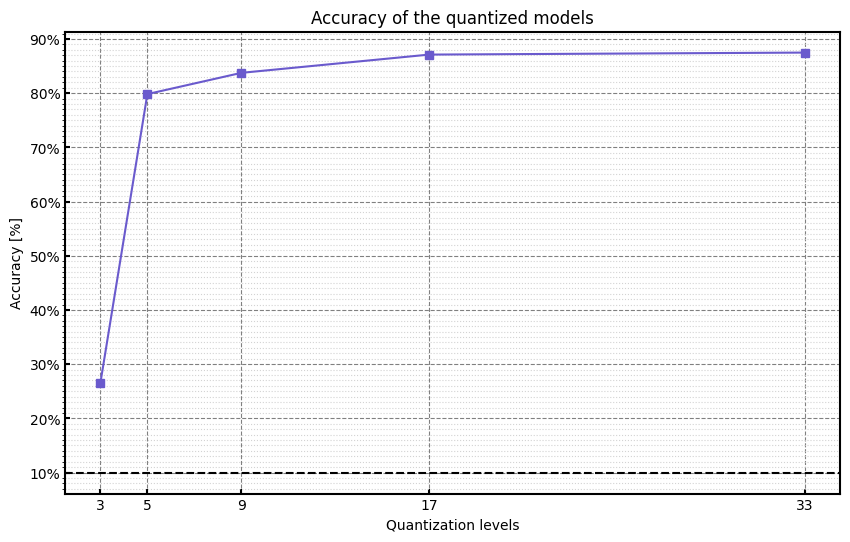

In [7]:
# Plot the accuracies
fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(list(accuracy_quantized.keys()), list(accuracy_quantized.values()), marker = "s", color = "slateblue")
ax.axhline(y = accuracy_non_quantized, color = "k", linestyle = "--")
ax.set_xlabel("Quantization levels")
ax.set_ylabel("Accuracy [%]")
ax.set_title("Accuracy of the quantized models")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
# set the minor ticks on the y-axis
ax.yaxis.set_minor_locator(plt.MultipleLocator(1))
ax.xaxis.set_ticks(list(accuracy_quantized.keys()))
# ticks inside the plot
ax.tick_params(axis = "both", direction = "in")
ax.grid(which = "major", linestyle = "--", color = "gray")
ax.grid(which = "minor", linestyle = ":", color = "lightgray")
#make the outer box of the plot thicker
for _, spine in ax.spines.items():
    spine.set_linewidth(1.5)
# same with the ticks
ax.tick_params(width = 1.5)

Files already downloaded and verified
Files already downloaded and verified
Accuracy of the non-quantized model: 51.92%


<Figure size 1500x600 with 0 Axes>